# EDA cho PhysioNet/CinC 2019 Sepsis (luồng `data/`)

Notebook này phân tích dữ liệu thô (`.psv`) để hiểu rõ dataset trước khi thiết kế lại pipeline xử lý (kết hợp ưu điểm của `data/cleaning.py` + `data/feature-engineering.py` và của `reproduce/`).

Quy ước đường dẫn giống `data-pipeline.ipynb`: dataset local nằm trong `data/raw/` (ví dụ `data/raw/training_setA`, `data/raw/training_setB`), không commit vào git.

## 0. Thiết lập môi trường và đường dẫn

In [2]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

IS_KAGGLE = os.path.exists("/kaggle/input")

if IS_KAGGLE:
    # Tren Kaggle: du lieu nam duoi /kaggle/input (co the la .zip hoac da giai nen san),
    # giai nen (idempotent) vao /kaggle/working/data/raw.
    BASE_DIR = Path("/kaggle/working")
    PROJECT_ROOT = BASE_DIR
    DATA_DIR = BASE_DIR / "data"
    RAW_DIR = DATA_DIR / "raw"
    RAW_DIR.mkdir(parents=True, exist_ok=True)

    def extract_all_zips(search_root: Path, dest_root: Path) -> None:
        for zip_path in search_root.rglob("*.zip"):
            marker = dest_root / f".extracted_{zip_path.name}.done"
            if marker.exists():
                continue
            print(f"Giai nen {zip_path} -> {dest_root}")
            with zipfile.ZipFile(zip_path) as zf:
                zf.extractall(dest_root)
            marker.touch()

    extract_all_zips(Path("/kaggle/input"), RAW_DIR)
    if not any(RAW_DIR.rglob("*.psv")):
        # Dataset co the da duoc Kaggle tu giai nen san khi upload -> tim thang trong /kaggle/input
        RAW_DIR = Path("/kaggle/input")
else:
    # Local: gia dinh dataset da duoc tai/giai nen san vao data/raw (khong commit vao git).
    CURRENT_DIR = Path.cwd()
    DATA_DIR = CURRENT_DIR if (CURRENT_DIR / "cleaning.py").exists() else CURRENT_DIR / "data"
    PROJECT_ROOT = DATA_DIR.parent
    RAW_DIR = DATA_DIR / "raw"

pd.set_option("display.max_columns", 100)

print(f"Moi truong: {'Kaggle' if IS_KAGGLE else 'Local'}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"RAW_DIR: {RAW_DIR}")

Moi truong: Kaggle
DATA_DIR: /kaggle/working/data
RAW_DIR: /kaggle/input


## 1. Tìm file `.psv` và tạo manifest bệnh nhân

`rglob` được dùng thay vì `glob` cố định 1 cấp thư mục vì cách giải nén dataset có thể tạo thêm lớp thư mục con lồng nhau. `source` (Set A/B) được suy ra theo cả tên thư mục lẫn mã số `patient_id` (phòng trường hợp đường dẫn không còn giữ tên `training_setA/B` sau khi giải nén lại) — theo đúng quy tắc mã hoá mô tả trong `DATASET_OVERVIEW.md` (`p000001-p020336` = Set A, `p100001-p120000` = Set B).

In [3]:
def classify_source(file_path: Path, patient_id: str) -> str:
    path_str = str(file_path)
    if "training_setA" in path_str:
        return "A"
    if "training_setB" in path_str:
        return "B"
    # Fallback: suy ra tu ma so benh nhan (p000001-p020336 = A, p100001-p120000 = B)
    try:
        num = int(patient_id[1:])
    except ValueError:
        return "unknown"
    return "A" if num < 100000 else "B"


psv_files = sorted(RAW_DIR.rglob("*.psv"))
if not psv_files:
    raise FileNotFoundError(
        "Khong tim thay file .psv trong data/raw. Hay tai/giai nen dataset vao data/raw truoc "
        "(vi du: kaggle datasets download -d nguyenhoangthaotrinh/sepsyd-data)."
    )

manifest = pd.DataFrame({"file_path": psv_files})
manifest["patient_id"] = manifest["file_path"].map(lambda p: p.stem)
manifest["source"] = manifest.apply(lambda row: classify_source(row["file_path"], row["patient_id"]), axis=1)

print(f"So benh nhan tim thay: {len(manifest):,}")
display(manifest.head())
display(manifest["source"].value_counts(dropna=False).rename("n_patients"))

So benh nhan tim thay: 40,336


,file_path,patient_id,source
0,/kaggle/input/datasets/nguyenhoangthaotrinh/se...,p000001,A
1,/kaggle/input/datasets/nguyenhoangthaotrinh/se...,p000002,A
2,/kaggle/input/datasets/nguyenhoangthaotrinh/se...,p000003,A
3,/kaggle/input/datasets/nguyenhoangthaotrinh/se...,p000004,A
4,/kaggle/input/datasets/nguyenhoangthaotrinh/se...,p000005,A


source
A    20336
B    20000
Name: n_patients, dtype: int64

In [4]:
def load_patient(file_path: Path, patient_id: str, source: str) -> pd.DataFrame:
    df = pd.read_csv(file_path, sep="|")
    df.insert(0, "patient_id", patient_id)
    df.insert(1, "source", source)
    return df


# `patients`: list (patient_id, df, source) - tien cho phan tich theo tung benh nhan (VD EDA muc 6:
# xu huong truoc khi khoi phat sepsis).
patients = [
    (row.patient_id, load_patient(row.file_path, row.patient_id, row.source), row.source)
    for row in manifest.itertuples(index=False)
]

# `raw_df`: gop tat ca benh nhan thanh 1 DataFrame - tien cho thong ke tong quan/groupby toan dataset.
raw_df = pd.concat([df for _, df, _ in patients], ignore_index=True)

print(f"So benh nhan da load: {len(patients):,}")
print(f"Tong so dong (gio ICU): {len(raw_df):,}")
print(f"Bo nho su dung: {raw_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
display(raw_df.head())
display(raw_df.dtypes)

So benh nhan da load: 40,336
Tong so dong (gio ICU): 1,552,210
Bo nho su dung: 642.5 MB


,patient_id,source,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,p000001,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,p000001,A,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,p000001,A,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,p000001,A,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,NaN,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,p000001,A,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


patient_id           object
source               object
HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2               float64
SaO2                float64
AST                 float64
BUN                 float64
Alkalinephos        float64
Calcium             float64
Chloride            float64
Creatinine          float64
Bilirubin_direct    float64
Glucose             float64
Lactate             float64
Magnesium           float64
Phosphate           float64
Potassium           float64
Bilirubin_total     float64
TroponinI           float64
Hct                 float64
Hgb                 float64
PTT                 float64
WBC                 float64
Fibrinogen          float64
Platelets           

## 2. Phân tích dữ liệu thiếu (Missing Data)

Dataset đo theo giờ nhưng không phải biến nào cũng được đo mỗi giờ: vitals (HR, O2Sat, ...) thường lấy tự động qua monitor nên khá dày, trong khi các chỉ số xét nghiệm (labs) chỉ được lấy khi bác sĩ chỉ định, nên tỉ lệ thiếu của 2 nhóm này rất khác nhau. Phần này đánh giá:

1. Tỉ lệ thiếu tổng thể theo từng cột và theo nhóm biến (vitals / labs / demographics).
2. Tỉ lệ thiếu có khác nhau giữa Set A và Set B (2 hệ thống bệnh viện, có thể khác protocol xét nghiệm) không.
3. Missingness có mang tính thông tin (informative) hay không — tức tỉ lệ thiếu có tương quan với `SepsisLabel` không.
4. Mức độ đầy đủ dữ liệu lab tính theo từng bệnh nhân (khác với thiếu tại 1 giờ cụ thể — có thể có bệnh nhân không bao giờ được đo một chỉ số nào đó).
5. Xu hướng thiếu dữ liệu thay đổi thế nào theo thời gian nằm ICU (`ICULOS`).

Các quan sát ở đây sẽ định hướng chiến lược impute (forward-fill theo bệnh nhân, hay thêm feature "is_missing"/"time since last measurement") ở bước feature engineering.

In [5]:
import matplotlib.pyplot as plt

VITAL_COLS = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "EtCO2"]
LAB_COLS = [
    "BaseExcess", "HCO3", "FiO2", "pH", "PaCO2", "SaO2", "AST", "BUN",
    "Alkalinephos", "Calcium", "Chloride", "Creatinine", "Bilirubin_direct",
    "Glucose", "Lactate", "Magnesium", "Phosphate", "Potassium",
    "Bilirubin_total", "TroponinI", "Hct", "Hgb", "PTT", "WBC",
    "Fibrinogen", "Platelets",
]
DEMO_COLS = ["Age", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS"]


def feature_group(col: str) -> str:
    if col in VITAL_COLS:
        return "vital"
    if col in LAB_COLS:
        return "lab"
    if col in DEMO_COLS:
        return "demographic"
    return "other"


feature_cols = [c for c in raw_df.columns if c not in ("patient_id", "source", "SepsisLabel")]

missing_summary = pd.DataFrame({
    "column": feature_cols,
    "n_missing": raw_df[feature_cols].isna().sum().values,
    "pct_missing": (raw_df[feature_cols].isna().mean() * 100).values,
})
missing_summary["group"] = missing_summary["column"].map(feature_group)
missing_summary = missing_summary.sort_values("pct_missing", ascending=False).reset_index(drop=True)

print(f"So dong (gio ICU): {len(raw_df):,}")
display(missing_summary)
display(missing_summary.groupby("group")["pct_missing"].agg(["mean", "min", "max"]).round(1))

So dong (gio ICU): 1,552,210


,column,n_missing,pct_missing,group
0,Bilirubin_direct,1549220,99.807371,lab
1,Fibrinogen,1541968,99.340167,lab
2,TroponinI,1537429,99.047745,lab
3,Bilirubin_total,1529069,98.509158,lab
4,Alkalinephos,1527269,98.393194,lab
5,AST,1527027,98.377604,lab
6,Lactate,1510764,97.329872,lab
7,PTT,1506511,97.055875,lab
8,SaO2,1498649,96.549372,lab
9,EtCO2,1494574,96.286843,vital


,mean,min,max
group,,,
demographic,13.1,0.0,39.4
lab,94.8,82.9,99.8
vital,32.4,9.9,96.3


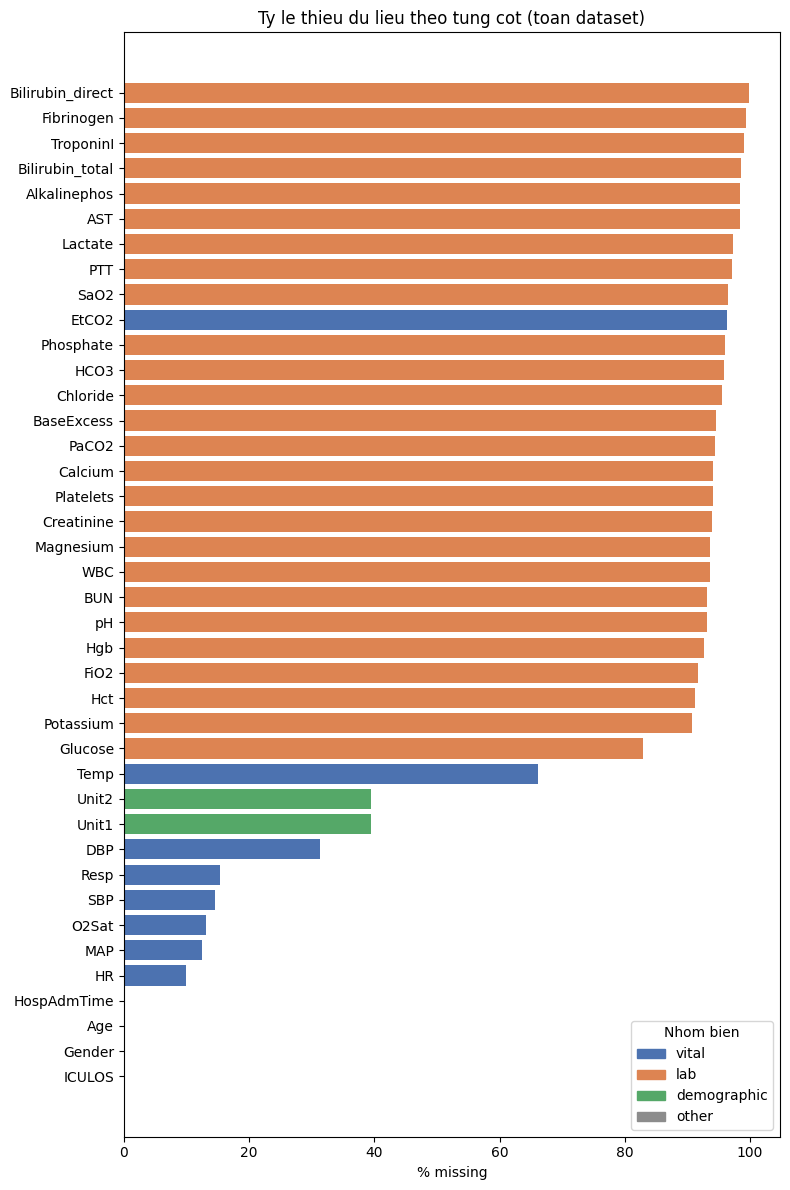

In [6]:
group_colors = {"vital": "#4C72B0", "lab": "#DD8452", "demographic": "#55A868", "other": "#8C8C8C"}
colors = missing_summary["group"].map(group_colors)

fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(missing_summary["column"], missing_summary["pct_missing"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("% missing")
ax.set_title("Ty le thieu du lieu theo tung cot (toan dataset)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in group_colors.values()]
ax.legend(handles, group_colors.keys(), loc="lower right", title="Nhom bien")
plt.tight_layout()
plt.show()

### 2.1 Missing theo nguồn dữ liệu (Set A vs Set B)

Set A và Set B đến từ 2 hệ thống bệnh viện khác nhau nên có thể có protocol chỉ định xét nghiệm khác nhau, dẫn đến tỉ lệ thiếu khác nhau. So sánh giúp quyết định có cần xử lý/impute riêng theo `source` hay không.

source,A,B,diff_A_minus_B
DBP,48.1,13.9,34.2
Unit2,48.9,29.6,19.2
Unit1,48.9,29.6,19.2
Glucose,87.8,77.8,9.9
EtCO2,100.0,92.4,7.6
Calcium,95.0,93.2,1.9
TroponinI,99.9,98.2,1.7
SBP,15.2,13.9,1.3
Bilirubin_total,98.8,98.2,0.5
Alkalinephos,98.5,98.2,0.3


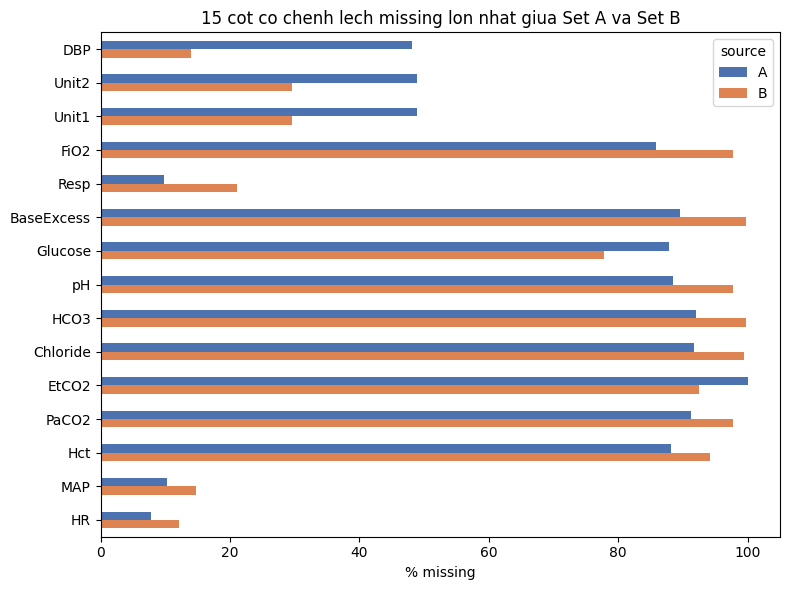

In [7]:
missing_by_source = (
    raw_df.groupby("source")[feature_cols].apply(lambda d: d.isna().mean() * 100).T
)
missing_by_source["diff_A_minus_B"] = missing_by_source.get("A", 0) - missing_by_source.get("B", 0)
missing_by_source = missing_by_source.sort_values("diff_A_minus_B", ascending=False)
display(missing_by_source.round(1))

top_diff_cols = missing_by_source["diff_A_minus_B"].abs().sort_values(ascending=False).head(15).index
fig, ax = plt.subplots(figsize=(8, 6))
missing_by_source.loc[top_diff_cols, ["A", "B"]].plot(kind="barh", ax=ax, color=["#4C72B0", "#DD8452"])
ax.invert_yaxis()
ax.set_xlabel("% missing")
ax.set_title("15 cot co chenh lech missing lon nhat giua Set A va Set B")
plt.tight_layout()
plt.show()

### 2.2 Missingness có mang tính thông tin không? (so với `SepsisLabel`)

Nếu tỉ lệ thiếu khác biệt rõ giữa nhóm `SepsisLabel=1` và `=0` thì bản thân việc thiếu dữ liệu đã là một tín hiệu hữu ích (ví dụ: bệnh nhân nặng/nghi sepsis thường được chỉ định xét nghiệm nhiều hơn nên ít thiếu hơn). Nếu đúng vậy, nên cân nhắc thêm feature dạng `is_missing`/`time_since_last_measurement` thay vì chỉ impute rồi bỏ qua.

,pct_missing_label0,pct_missing_label1,diff
FiO2,91.84,82.02,9.82
EtCO2,96.42,89.26,7.15
pH,93.19,86.64,6.55
PaCO2,94.55,88.70,5.85
Unit1,39.32,45.07,-5.75
Unit2,39.32,45.07,-5.75
BaseExcess,94.67,89.77,4.90
Lactate,97.41,92.98,4.43
Potassium,90.76,86.81,3.95
SaO2,96.60,93.51,3.09


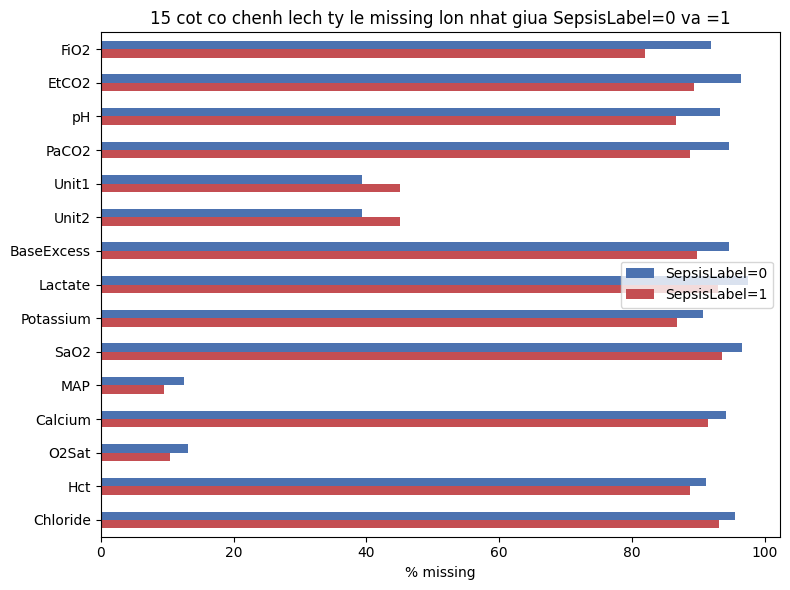

In [8]:
missing_by_label = (
    raw_df.groupby("SepsisLabel")[feature_cols].apply(lambda d: d.isna().mean() * 100).T
)
missing_by_label.columns = ["pct_missing_label0", "pct_missing_label1"]
missing_by_label["diff"] = missing_by_label["pct_missing_label0"] - missing_by_label["pct_missing_label1"]
missing_by_label = missing_by_label.reindex(missing_by_label["diff"].abs().sort_values(ascending=False).index)
display(missing_by_label.round(2))

top_label_diff = missing_by_label.head(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_label_diff[["pct_missing_label0", "pct_missing_label1"]].plot(
    kind="barh", ax=ax, color=["#4C72B0", "#C44E52"]
)
ax.invert_yaxis()
ax.set_xlabel("% missing")
ax.set_title("15 cot co chenh lech ty le missing lon nhat giua SepsisLabel=0 va =1")
ax.legend(["SepsisLabel=0", "SepsisLabel=1"])
plt.tight_layout()
plt.show()

### 2.3 Mức độ đầy đủ dữ liệu theo từng bệnh nhân

Thiếu tại 1 giờ cụ thể (có thể forward-fill từ lần đo gần nhất của cùng bệnh nhân) khác với việc một bệnh nhân **chưa bao giờ** được đo một chỉ số lab nào đó trong suốt thời gian nằm ICU (forward-fill không giúp được, phải impute bằng giá trị population/nhóm hoặc bỏ feature). Đo tỉ lệ % số lab từng có ít nhất 1 giá trị non-null trong toàn bộ record của mỗi bệnh nhân.

/tmp/ipykernel_58/1958083367.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_patient_completeness = raw_df.groupby("patient_id").apply(pct_labs_ever_recorded)


count    40336.000000
mean        58.745957
std         18.913187
min          0.000000
25%         50.000000
50%         57.692308
75%         73.076923
max        100.000000
Name: pct_labs_ever_recorded, dtype: float64

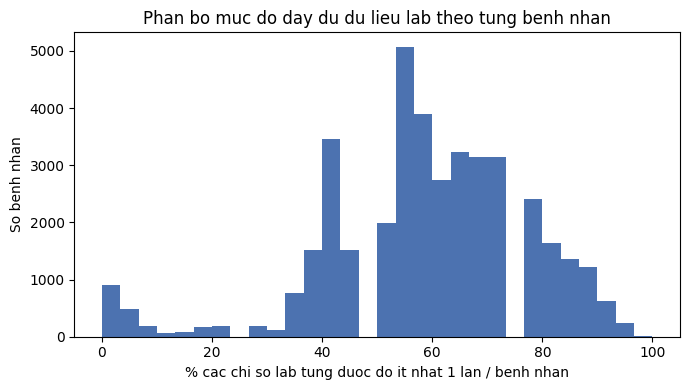

In [9]:
def pct_labs_ever_recorded(df: pd.DataFrame) -> float:
    return df[LAB_COLS].notna().any(axis=0).mean() * 100


per_patient_completeness = raw_df.groupby("patient_id").apply(pct_labs_ever_recorded)
per_patient_completeness.name = "pct_labs_ever_recorded"

display(per_patient_completeness.describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(per_patient_completeness, bins=30, color="#4C72B0")
ax.set_xlabel("% cac chi so lab tung duoc do it nhat 1 lan / benh nhan")
ax.set_ylabel("So benh nhan")
ax.set_title("Phan bo muc do day du du lieu lab theo tung benh nhan")
plt.tight_layout()
plt.show()

### 2.4 Xu hướng thiếu dữ liệu theo thời gian nằm ICU (`ICULOS`)

Lab thường được lấy vào đầu đợt nằm viện hoặc khi có chỉ định lâm sàng mới. Kiểm tra xem tỉ lệ thiếu có thay đổi theo `ICULOS` (số giờ kể từ khi nhập ICU) hay không — ví dụ nếu bệnh nhân nằm càng lâu càng được theo dõi sát hơn (tỉ lệ thiếu giảm), hay ngược lại các giờ đầu được xét nghiệm dày hơn rồi thưa dần.

,HR,Lactate,Creatinine,WBC,Platelets
ICULOS,,,,,
"(0, 6]",19.5,95.1,92.0,91.4,92.0
"(6, 12]",7.3,96.3,92.4,92.1,92.5
"(12, 24]",8.8,97.7,94.8,94.5,95.0
"(24, 48]",8.6,98.4,94.6,94.3,94.7
"(48, 96]",7.4,97.6,94.3,94.2,94.7
"(96, 336]",6.5,97.7,94.3,94.2,94.7


ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of labels (6).

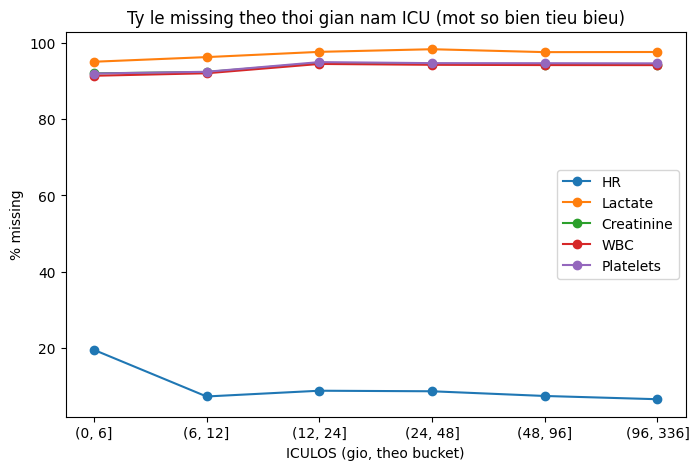

In [11]:
iculos_bucket = pd.cut(raw_df["ICULOS"], bins=[0, 6, 12, 24, 48, 96, raw_df["ICULOS"].max()])
sample_cols = ["HR", "Lactate", "Creatinine", "WBC", "Platelets"]
missing_over_time = (
    raw_df.groupby(iculos_bucket, observed=True)[sample_cols]
    .apply(lambda d: d.isna().mean() * 100)
)

display(missing_over_time.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
missing_over_time.plot(ax=ax, marker="o")
ax.set_xlabel("ICULOS (gio, theo bucket)")
ax.set_ylabel("% missing")
ax.set_title("Ty le missing theo thoi gian nam ICU (mot so bien tieu bieu)")
ax.set_xticklabels([str(i) for i in missing_over_time.index], rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Phân phối giá trị & Outliers theo domain knowledge

Sau khi biết dữ liệu thiếu bao nhiêu (mục 2), phần này nhìn vào các giá trị **hiện có** để kiểm chứng 2 giả định cứng đang nằm trong `data/cleaning.py`:

- `PHYSIOLOGICAL_RANGES` trong `cleaning.py` chỉ định nghĩa ngưỡng lọc outlier cho **3 biến**: `Temp` (20–50°C), `O2Sat` (21–100%), `HR` (0–300 bpm). SBP/DBP/MAP/Resp và toàn bộ 26 lab **chưa có ngưỡng nào** dù đây là nhóm dễ có lỗi nhập liệu/đơn vị đo nhất.
- Luồng `reproduce/` (Luồng A) chọn biến cần log-transform tự động theo skewness (`|skew| > 1.0`) và tự nhận có 25/40 biến bị lệch mạnh — cần tái lập con số này trên chính dữ liệu để xác nhận.

Kết quả ở đây sẽ là input trực tiếp để mở rộng `PHYSIOLOGICAL_RANGES` và xác nhận danh sách biến cần log-transform.

,count,mean,std,min,1%,25%,50%,75%,99%,max,group
HospAdmTime,1552202.0,-56.13,162.26,-5366.86,-630.09,-47.05,-6.03,-0.04,0.00,23.99,demographic
Unit1,940250.0,0.50,0.50,0.00,0.00,0.00,0.00,1.00,1.00,1.00,demographic
Gender,1552210.0,0.56,0.50,0.00,0.00,0.00,1.00,1.00,1.00,1.00,demographic
Unit2,940250.0,0.50,0.50,0.00,0.00,0.00,1.00,1.00,1.00,1.00,demographic
ICULOS,1552210.0,26.99,29.01,1.00,1.00,11.00,21.00,34.00,166.00,336.00,demographic
Age,1552210.0,62.01,16.39,14.00,21.00,51.68,64.00,74.00,89.00,100.00,demographic
BaseExcess,84145.0,-0.69,4.29,-32.00,-13.00,-3.00,0.00,1.00,11.00,100.00,lab
TroponinI,14781.0,8.29,24.81,0.01,0.01,0.04,0.30,3.98,135.46,440.00,lab
Bilirubin_direct,2990.0,1.84,3.69,0.01,0.06,0.20,0.44,1.70,19.82,37.50,lab
FiO2,129365.0,0.55,11.12,-50.00,0.21,0.40,0.50,0.60,1.00,4000.00,lab


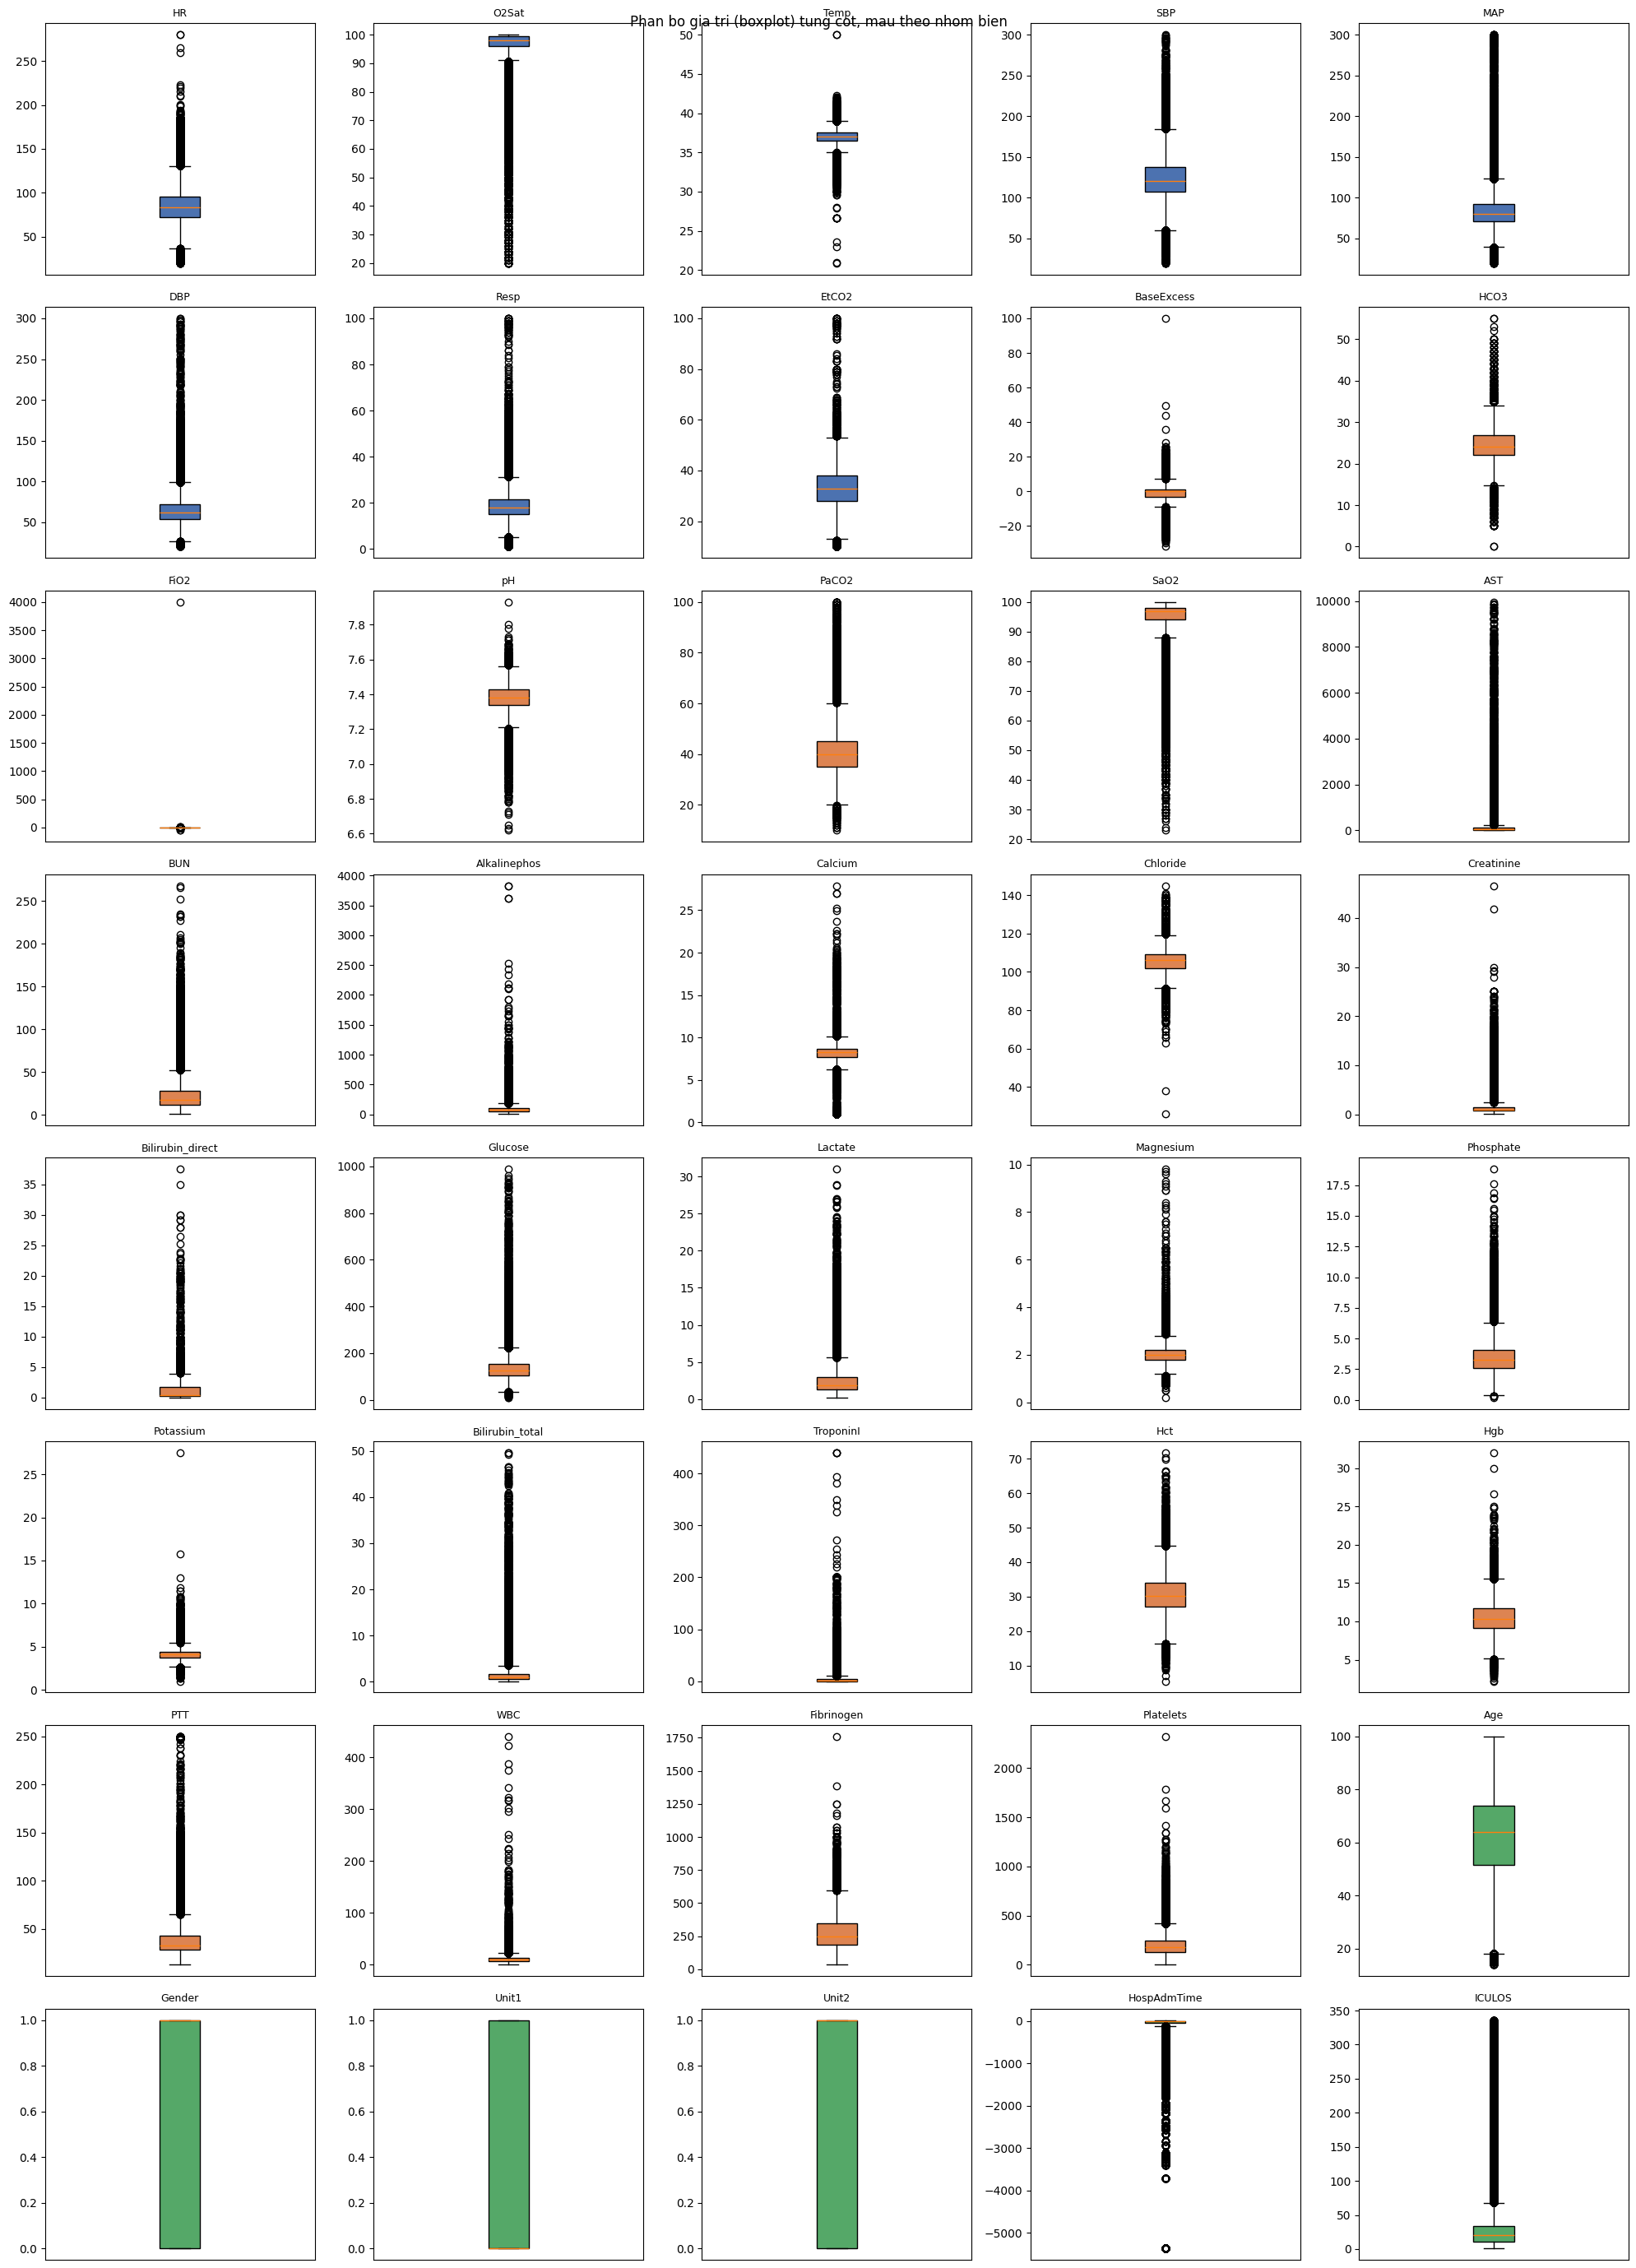

In [15]:
desc_stats = raw_df[feature_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
desc_stats["group"] = desc_stats.index.map(feature_group)
desc_stats = desc_stats.sort_values(["group", "50%"])
display(desc_stats.round(2))

fig, axes = plt.subplots(8, 5, figsize=(20, 28))
for ax, col in zip(axes.ravel(), feature_cols):
    data = raw_df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor=group_colors[feature_group(col)]))
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])
for ax in axes.ravel()[len(feature_cols):]:
    ax.axis("off")
fig.suptitle("Phan bo gia tri (boxplot) tung cot, mau theo nhom bien")
plt.tight_layout()
plt.show()

### 3.1 Kiểm chứng `PHYSIOLOGICAL_RANGES` hiện có trong `cleaning.py`

Áp trực tiếp `PHYSIOLOGICAL_RANGES` (import từ `data/cleaning.py`) lên `raw_df` để xem 3 ngưỡng này có thực sự bắt được outlier trong dữ liệu hay không.

In [16]:
import sys

if str(DATA_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_DIR))

from cleaning import PHYSIOLOGICAL_RANGES

outlier_check = []
for col, (lo, hi) in PHYSIOLOGICAL_RANGES.items():
    if col not in raw_df.columns:
        continue
    vals = pd.to_numeric(raw_df[col], errors="coerce")
    n_valid = vals.notna().sum()
    n_outside = ((vals < lo) | (vals > hi)).sum()
    outlier_check.append({
        "column": col,
        "range": f"[{lo}, {hi}]",
        "n_valid": n_valid,
        "n_outside_range": n_outside,
        "pct_outside": n_outside / n_valid * 100 if n_valid else 0.0,
    })

outlier_check_df = pd.DataFrame(outlier_check)
display(outlier_check_df.round(3))

ModuleNotFoundError: No module named 'cleaning'

### 3.2 Ngưỡng tham khảo cho các biến chưa có trong `PHYSIOLOGICAL_RANGES`

`cleaning.py` chưa định nghĩa ngưỡng cho SBP/DBP/MAP/Resp và 26 lab. Dưới đây là các khoảng "hợp lý sinh lý" **tham khảo** (dựa trên đơn vị đo mô tả trong `DATASET_OVERVIEW.md` và kiến thức lâm sàng phổ thông), cố tình chọn khoảng **rộng** để chỉ bắt các giá trị rõ ràng phi thực tế (lỗi nhập liệu/nhầm đơn vị), không đụng tới giá trị bất thường nhưng có thật về mặt lâm sàng. Đây không phải ngưỡng chính thức — cần bác sĩ/domain expert xác nhận lại trước khi đưa vào `cleaning.py`.

In [18]:
CANDIDATE_RANGES = {
    "SBP": (40, 300), "DBP": (20, 200), "MAP": (30, 200), "Resp": (0, 60), "EtCO2": (0, 100),
    "BaseExcess": (-30, 30), "HCO3": (5, 60), "FiO2": (21, 100), "pH": (6.5, 8.0),
    "PaCO2": (10, 150), "SaO2": (21, 100), "AST": (0, 10000), "BUN": (0, 200),
    "Alkalinephos": (0, 2000), "Calcium": (3, 20), "Chloride": (60, 140),
    "Creatinine": (0.1, 20), "Bilirubin_direct": (0, 30), "Glucose": (10, 1000),
    "Lactate": (0, 30), "Magnesium": (0.5, 5), "Phosphate": (0.5, 15), "Potassium": (1, 10),
    "Bilirubin_total": (0, 50), "TroponinI": (0, 100), "Hct": (10, 70), "Hgb": (2, 25),
    "PTT": (10, 200), "WBC": (0, 100), "Fibrinogen": (0, 1500), "Platelets": (0, 1500),
}

candidate_check = []
for col, (lo, hi) in CANDIDATE_RANGES.items():
    vals = pd.to_numeric(raw_df[col], errors="coerce")
    n_valid = vals.notna().sum()
    n_outside = ((vals < lo) | (vals > hi)).sum()
    candidate_check.append({
        "column": col,
        "candidate_range": f"[{lo}, {hi}]",
        "n_valid": n_valid,
        "n_outside_range": n_outside,
        "pct_outside": n_outside / n_valid * 100 if n_valid else 0.0,
    })

candidate_check_df = pd.DataFrame(candidate_check).sort_values("pct_outside", ascending=False)
display(candidate_check_df.round(3))

,column,candidate_range,n_valid,n_outside_range,pct_outside
7,FiO2,"[21, 100]",129365,129365,100.000
14,Calcium,"[3, 20]",91331,9920,10.862
24,TroponinI,"[0, 100]",14781,190,1.285
27,PTT,"[10, 200]",45699,140,0.306
20,Magnesium,"[0.5, 5]",97951,78,0.080
28,WBC,"[0, 100]",99447,73,0.073
17,Bilirubin_direct,"[0, 30]",2990,2,0.067
2,MAP,"[30, 200]",1358940,701,0.052
13,Alkalinephos,"[0, 2000]",24941,11,0.044
16,Creatinine,"[0.1, 20]",94616,38,0.040


### 3.3 Tái lập lựa chọn log-transform theo skewness (như Luồng A)

`reproduce/kaggle_reproduce_sepsis_best_config.ipynb` tự động chọn biến cần log-transform dựa trên `|skew| > 1.0` tính trên toàn bộ giá trị hợp lệ, và tự nhận có 25/40 biến bị lệch mạnh. Tính lại đúng công thức này để xác nhận con số đó có tái lập được trên dữ liệu thật không.

In [19]:
from scipy.stats import skew

skew_summary = []
for col in feature_cols:
    vals = pd.to_numeric(raw_df[col], errors="coerce").dropna()
    if len(vals) < 2:
        continue
    skew_summary.append({"column": col, "group": feature_group(col), "skew": skew(vals)})

skew_df = pd.DataFrame(skew_summary)
skew_df["is_skewed_gt1"] = skew_df["skew"].abs() > 1.0
skew_df = skew_df.reindex(skew_df["skew"].abs().sort_values(ascending=False).index)
display(skew_df.round(3))

n_skewed = skew_df["is_skewed_gt1"].sum()
print(f"So bien co |skew| > 1.0: {n_skewed}/{len(skew_df)} (Luong A tu nhan 25/40)")

,column,group,skew,is_skewed_gt1
10,FiO2,lab,359.332,True
31,WBC,lab,14.932,True
38,HospAdmTime,demographic,-12.266,True
16,Alkalinephos,lab,10.052,True
14,AST,lab,6.439,True
27,TroponinI,lab,6.392,True
26,Bilirubin_total,lab,5.267,True
19,Creatinine,lab,4.630,True
1,O2Sat,vital,-4.152,True
39,ICULOS,demographic,4.109,True


So bien co |skew| > 1.0: 25/40 (Luong A tu nhan 25/40)


## 4. Sepsis label & timing

`SepsisLabel` là biến mục tiêu, nhưng cũng là biến bị dịch sớm 6 giờ so với thời điểm khởi phát lâm sàng thật (`DATASET_OVERVIEW.md`). Phần này đo:

- Tỉ lệ dương tính theo bệnh nhân và theo dòng (chênh lệch giữa 2 con số này phản ánh độ dài trung bình của giai đoạn "đã sepsis" trong 1 lượt nằm ICU).
- Thời điểm `SepsisLabel=1` xuất hiện lần đầu so với lúc nhập ICU, và tổng thời gian nằm ICU — dùng để đánh giá cửa sổ lookback `H=5` giờ của Luồng A có đủ dữ liệu lịch sử hay không (nếu nhiều bệnh nhân sepsis ngay trong vài giờ đầu, H=5 sẽ không có đủ ngữ cảnh).

Ty le benh nhan tung co SepsisLabel=1 (toan bo): 7.27%
Ty le dong co SepsisLabel=1 (toan bo): 1.80%


,patient_level_pct,row_level_pct
source,,
A,8.80,2.17
B,5.71,1.41


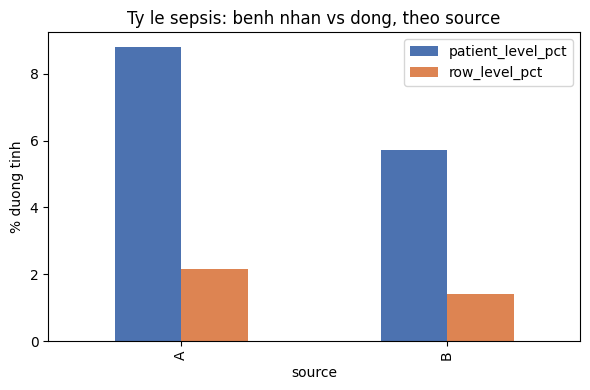

In [20]:
patient_label = raw_df.groupby("patient_id").agg(source=("source", "first"), ever_sepsis=("SepsisLabel", "max"))
patient_prevalence = patient_label.groupby("source")["ever_sepsis"].mean() * 100
row_prevalence = raw_df.groupby("source")["SepsisLabel"].mean() * 100

print(f"Ty le benh nhan tung co SepsisLabel=1 (toan bo): {patient_label['ever_sepsis'].mean() * 100:.2f}%")
print(f"Ty le dong co SepsisLabel=1 (toan bo): {raw_df['SepsisLabel'].mean() * 100:.2f}%")

summary_prevalence = pd.DataFrame({"patient_level_pct": patient_prevalence, "row_level_pct": row_prevalence})
display(summary_prevalence.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
summary_prevalence.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("% duong tinh")
ax.set_title("Ty le sepsis: benh nhan vs dong, theo source")
plt.tight_layout()
plt.show()

count    2932.000000
mean       50.896317
std        59.363675
min         1.000000
25%         7.000000
50%        29.000000
75%        73.000000
max       331.000000
Name: ICULOS, dtype: float64

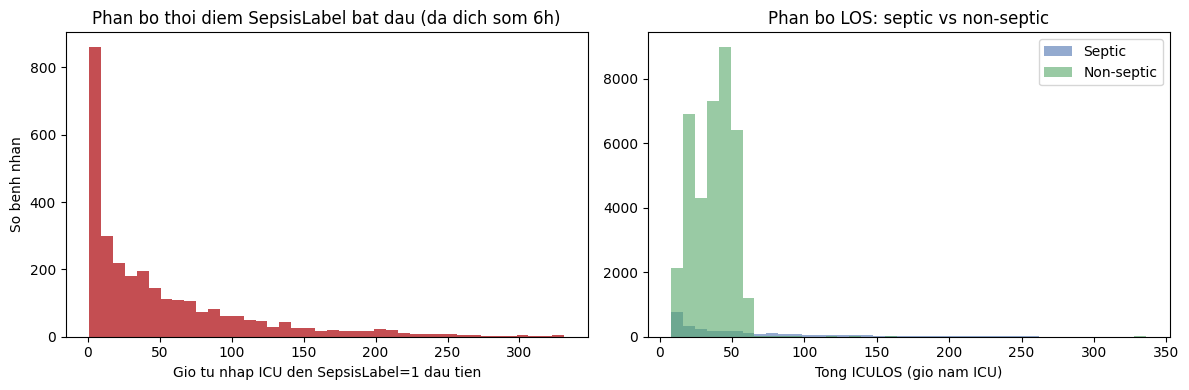

% benh nhan sepsis co SepsisLabel=1 xuat hien trong 5 gio dau ICU (khong du lich su cho H=5 lookback): 21.9%


In [22]:
septic_patients = patient_label[patient_label["ever_sepsis"] == 1].index

hours_to_onset = (
    raw_df[raw_df["patient_id"].isin(septic_patients) & (raw_df["SepsisLabel"] == 1)]
    .groupby("patient_id")["ICULOS"].min()
)
los_all = raw_df.groupby("patient_id")["ICULOS"].max()

display(hours_to_onset.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(hours_to_onset, bins=40, color="#C44E52")
axes[0].set_xlabel("Gio tu nhap ICU den SepsisLabel=1 dau tien")
axes[0].set_ylabel("So benh nhan")
axes[0].set_title("Phan bo thoi diem SepsisLabel bat dau (da dich som 6h)")

axes[1].hist(los_all[septic_patients], bins=40, color="#4C72B0", alpha=0.6, label="Septic")
axes[1].hist(los_all[~los_all.index.isin(septic_patients)], bins=40, color="#55A868", alpha=0.6, label="Non-septic")
axes[1].set_xlabel("Tong ICULOS (gio nam ICU)")
axes[1].set_title("Phan bo LOS: septic vs non-septic")
axes[1].legend()
plt.tight_layout()
plt.show()

pct_onset_before_h = (hours_to_onset <= 5).mean() * 100
print(f"% benh nhan sepsis co SepsisLabel=1 xuat hien trong 5 gio dau ICU (khong du lich su cho H=5 lookback): {pct_onset_before_h:.1f}%")

/tmp/ipykernel_58/1727141071.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


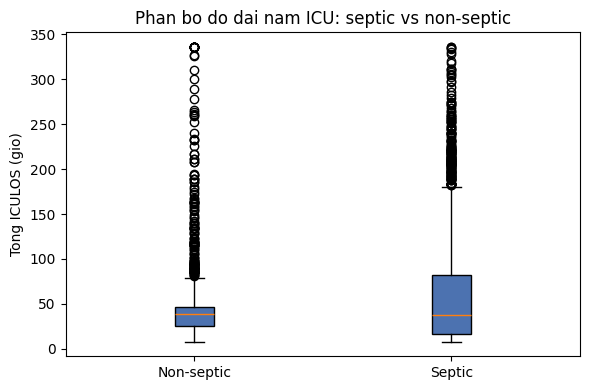

,count,mean,std,min,25%,50%,75%,max
ever_sepsis,,,,,,,,
0,37404.0,37.410437,15.956682,8.0,25.0,39.0,47.0,336.0
1,2932.0,59.417462,59.445450,8.0,16.0,38.0,82.0,336.0


In [23]:
los_df = pd.DataFrame({
    "ICULOS_max": los_all,
    "ever_sepsis": patient_label.loc[los_all.index, "ever_sepsis"],
})

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(
    [los_df.loc[los_df["ever_sepsis"] == 0, "ICULOS_max"], los_df.loc[los_df["ever_sepsis"] == 1, "ICULOS_max"]],
    labels=["Non-septic", "Septic"],
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0"),
)
ax.set_ylabel("Tong ICULOS (gio)")
ax.set_title("Phan bo do dai nam ICU: septic vs non-septic")
plt.tight_layout()
plt.show()

display(los_df.groupby("ever_sepsis")["ICULOS_max"].describe())

## 5. Tương quan biến & Redundancy

Cả 2 luồng hiện tại đều coi 26 lab là độc lập (Luồng A tạo Mask cho từng biến riêng, Luồng B không có bước loại trừ trùng lặp). Phần này kiểm tra mức độ tương quan giữa các biến để biết có dư thừa đáng kể không (gợi ý cho feature selection/PCA sau này), và xếp hạng biến nào có tương quan mạnh nhất với `SepsisLabel` (tín hiệu đơn biến, tham chiếu chéo với mục 8 khi chọn ưu tiên mask).

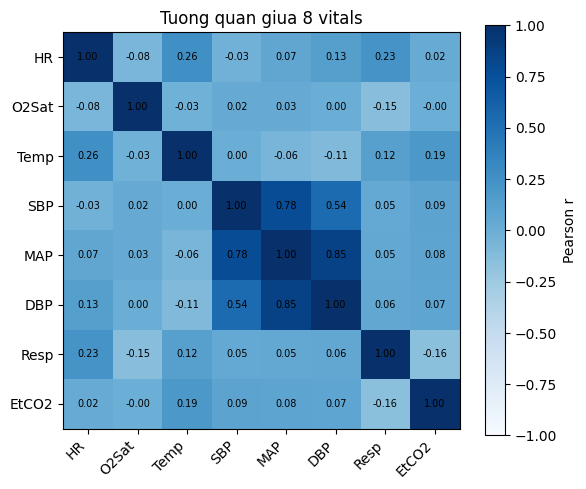

In [24]:
vital_corr = raw_df[VITAL_COLS].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(vital_corr, cmap="Blues", vmin=-1, vmax=1)
ax.set_xticks(range(len(VITAL_COLS)))
ax.set_xticklabels(VITAL_COLS, rotation=45, ha="right")
ax.set_yticks(range(len(VITAL_COLS)))
ax.set_yticklabels(VITAL_COLS)
for i in range(len(VITAL_COLS)):
    for j in range(len(VITAL_COLS)):
        ax.text(j, i, f"{vital_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Tuong quan giua 8 vitals")
plt.tight_layout()
plt.show()

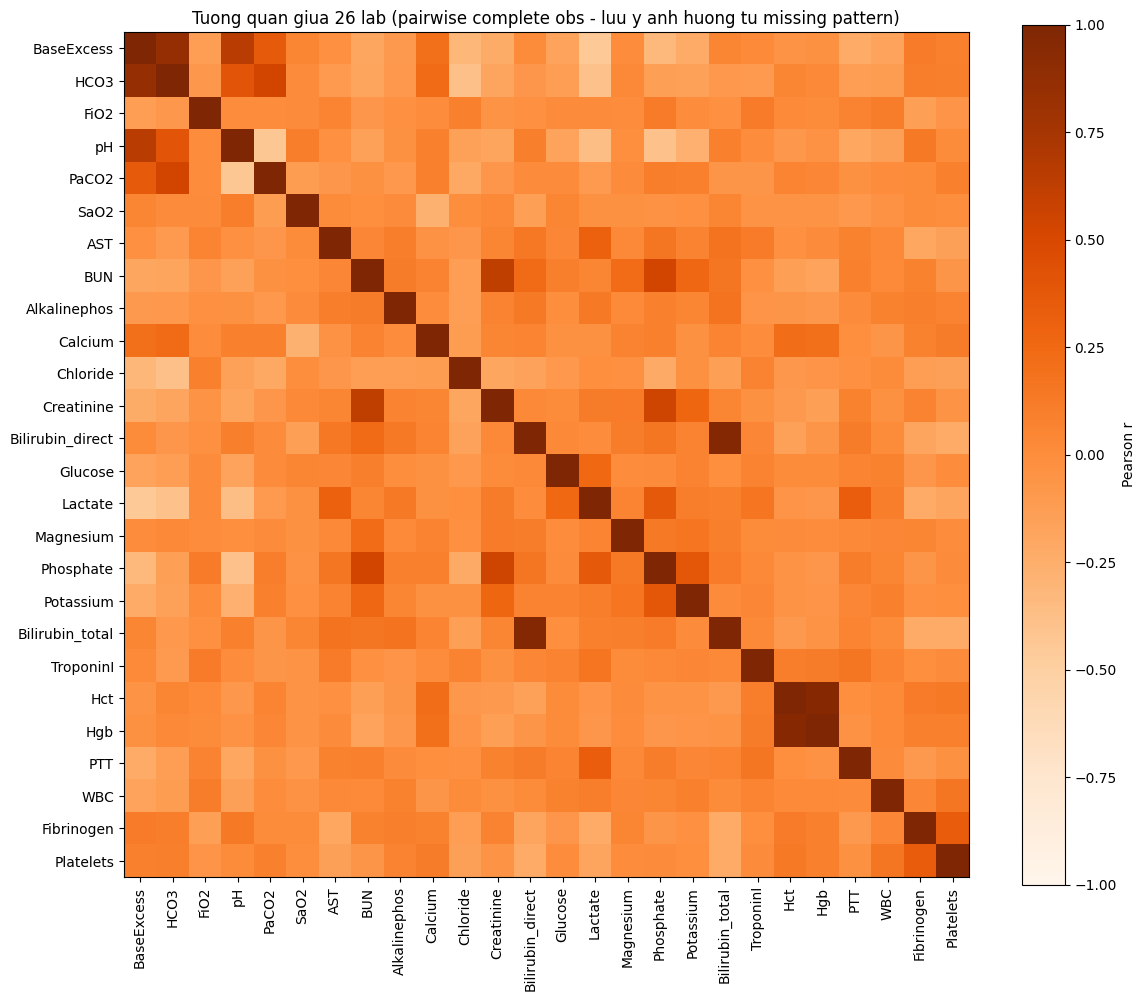

Bilirubin_direct  Bilirubin_total    0.963987
Hct               Hgb                0.952208
BaseExcess        HCO3               0.856930
                  pH                 0.650621
BUN               Creatinine         0.623934
Creatinine        Phosphate          0.548615
HCO3              PaCO2              0.538653
BUN               Phosphate          0.534115
BaseExcess        Lactate           -0.447899
pH                PaCO2             -0.436862
HCO3              Lactate           -0.406001
                  pH                 0.400755
pH                Phosphate         -0.395798
HCO3              Chloride          -0.384768
Phosphate         Potassium          0.379061
dtype: float64

In [25]:
lab_corr = raw_df[LAB_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(lab_corr, cmap="Oranges", vmin=-1, vmax=1)
ax.set_xticks(range(len(LAB_COLS)))
ax.set_xticklabels(LAB_COLS, rotation=90)
ax.set_yticks(range(len(LAB_COLS)))
ax.set_yticklabels(LAB_COLS)
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Tuong quan giua 26 lab (pairwise complete obs - luu y anh huong tu missing pattern)")
plt.tight_layout()
plt.show()

high_corr_pairs = (
    lab_corr.where(np.triu(np.ones(lab_corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(high_corr_pairs.head(15))

ICULOS              0.134
Bilirubin_direct    0.058
BUN                 0.053
HR                  0.049
Fibrinogen          0.048
Temp                0.048
Bilirubin_total     0.048
Resp                0.046
Calcium            -0.040
WBC                 0.038
Creatinine          0.029
Unit1               0.025
Unit2              -0.025
Phosphate           0.020
HospAdmTime        -0.019
MAP                -0.019
Hgb                -0.019
DBP                -0.018
PTT                 0.017
EtCO2              -0.015
Hct                -0.015
PaCO2               0.015
BaseExcess          0.015
HCO3               -0.014
Alkalinephos        0.013
SBP                -0.013
Platelets          -0.012
Chloride           -0.010
SaO2                0.010
O2Sat              -0.009
Gender              0.009
Glucose             0.008
AST                 0.008
TroponinI           0.007
Lactate             0.007
Magnesium           0.006
Potassium           0.006
pH                 -0.005
Age         

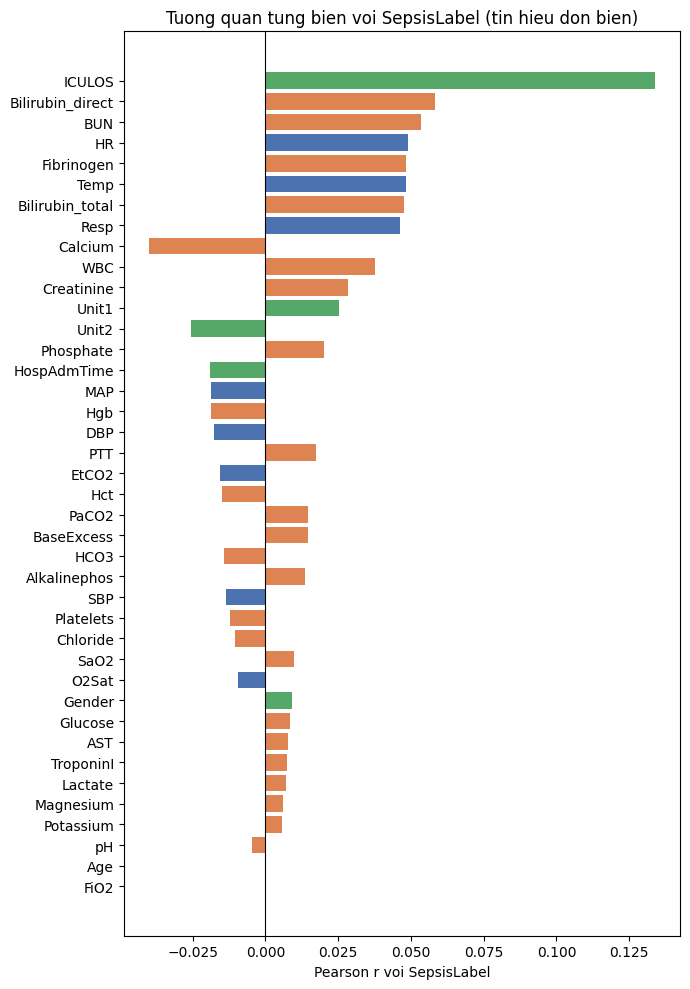

In [26]:
corr_with_label = raw_df[feature_cols + ["SepsisLabel"]].corr()["SepsisLabel"].drop("SepsisLabel")
corr_with_label = corr_with_label.reindex(corr_with_label.abs().sort_values(ascending=False).index)

display(corr_with_label.round(3))

fig, ax = plt.subplots(figsize=(7, 10))
colors_corr = [group_colors[feature_group(c)] for c in corr_with_label.index]
ax.barh(corr_with_label.index, corr_with_label.values, color=colors_corr)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r voi SepsisLabel")
ax.set_title("Tuong quan tung bien voi SepsisLabel (tin hieu don bien)")
plt.tight_layout()
plt.show()

## 6. Xu hướng trước khi khởi phát sepsis

Đúng như comment đã để sẵn ở mục 1 (`patients`: tiện cho EDA mục 6), phần này căn chỉnh dữ liệu theo **giờ tương đối so với thời điểm khởi phát sepsis thật** `t_sepsis` — không phải theo `ICULOS` tuyệt đối. Vì `SepsisLabel` đã bị dịch sớm 6 giờ (`DATASET_OVERVIEW.md`), `t_sepsis` (giờ khởi phát lâm sàng thật) = giờ đầu tiên `SepsisLabel == 1` + 6.

Việc này cần lặp theo từng bệnh nhân (không vector hóa được trên `raw_df` toàn cục), nên **lấy mẫu ngẫu nhiên** (mặc định 400 bệnh nhân sepsis, seed cố định để tái lập) thay vì lặp hết ~40k bệnh nhân — nếu cần chạy full dataset sau này, logic tương tự có thể vector hóa bằng `groupby("patient_id").apply(...)` với offset giờ tương đối.

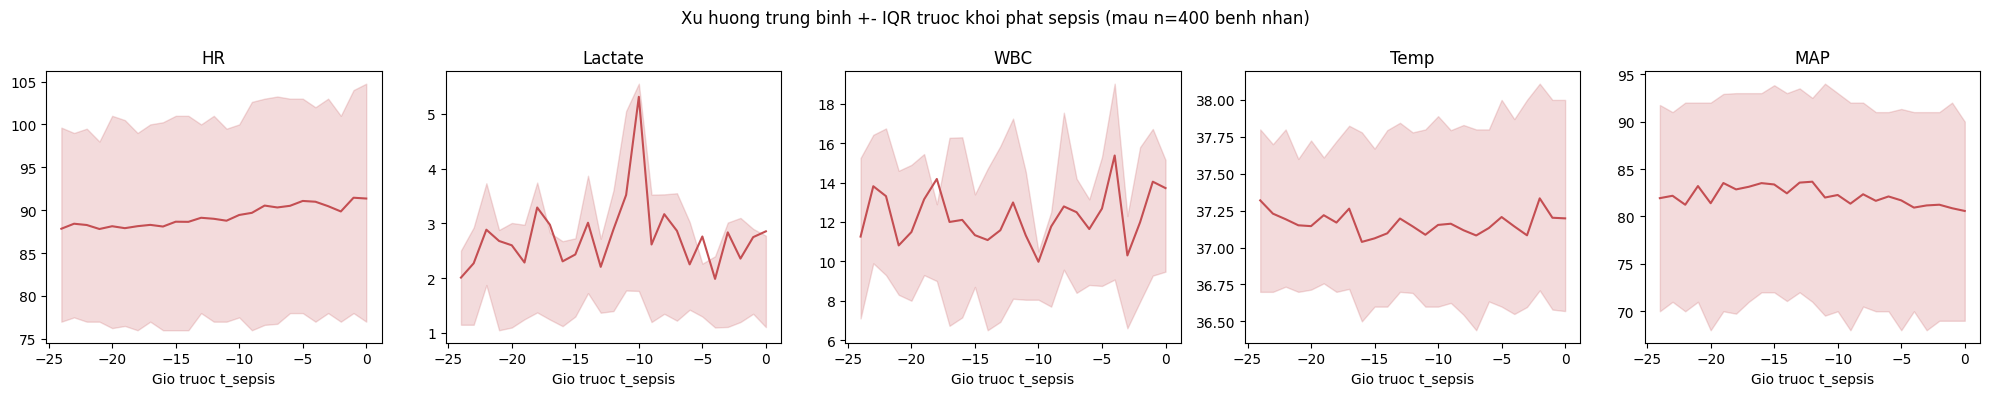

In [27]:
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

TRAJ_COLS = ["HR", "Lactate", "WBC", "Temp", "MAP"]
SAMPLE_SIZE = 400

patients_by_id = {pid: df for pid, df, _ in patients}
septic_sample_ids = rng.choice(np.array(septic_patients), size=min(SAMPLE_SIZE, len(septic_patients)), replace=False)


def relative_hours_to_onset(df: pd.DataFrame) -> pd.Series:
    onset_idx = df.index[df["SepsisLabel"] == 1]
    if len(onset_idx) == 0:
        return pd.Series(dtype=float)
    t_sepsis_label_hour = df.loc[onset_idx[0], "ICULOS"]
    t_sepsis_actual = t_sepsis_label_hour + 6  # label da dich som 6h so voi khoi phat that
    return df["ICULOS"] - t_sepsis_actual


records = []
for pid in septic_sample_ids:
    df = patients_by_id[pid]
    rel_hours = relative_hours_to_onset(df)
    mask = (rel_hours >= -24) & (rel_hours <= 0)
    if mask.sum() == 0:
        continue
    sub = df.loc[mask, TRAJ_COLS].copy()
    sub["rel_hour"] = rel_hours[mask].round().astype(int)
    sub["patient_id"] = pid
    records.append(sub)

septic_traj = pd.concat(records, ignore_index=True)

fig, axes = plt.subplots(1, len(TRAJ_COLS), figsize=(20, 4), sharex=True)
for ax, col in zip(axes, TRAJ_COLS):
    grouped = septic_traj.groupby("rel_hour")[col]
    mean_ = grouped.mean()
    q25 = grouped.quantile(0.25)
    q75 = grouped.quantile(0.75)
    ax.plot(mean_.index, mean_.values, color="#C44E52")
    ax.fill_between(mean_.index, q25.values, q75.values, color="#C44E52", alpha=0.2)
    ax.set_title(col)
    ax.set_xlabel("Gio truoc t_sepsis")
fig.suptitle(f"Xu huong trung binh +- IQR truoc khoi phat sepsis (mau n={len(septic_sample_ids)} benh nhan)")
plt.tight_layout()
plt.show()

### 6.1 So sánh với nhóm đối chứng (non-septic)

Bệnh nhân không sepsis không có thời điểm khởi phát để căn theo, nên căn theo **thời điểm cuối kỳ nằm ICU** (giờ 0 = giờ cuối cùng có dữ liệu) để so sánh hình dạng xu hướng — giúp phân biệt xu hướng đặc trưng cho sepsis với xu hướng suy giảm ICU nói chung (bệnh nhân ICU nào cũng có thể có dấu hiệu bất ổn ở cuối kỳ).

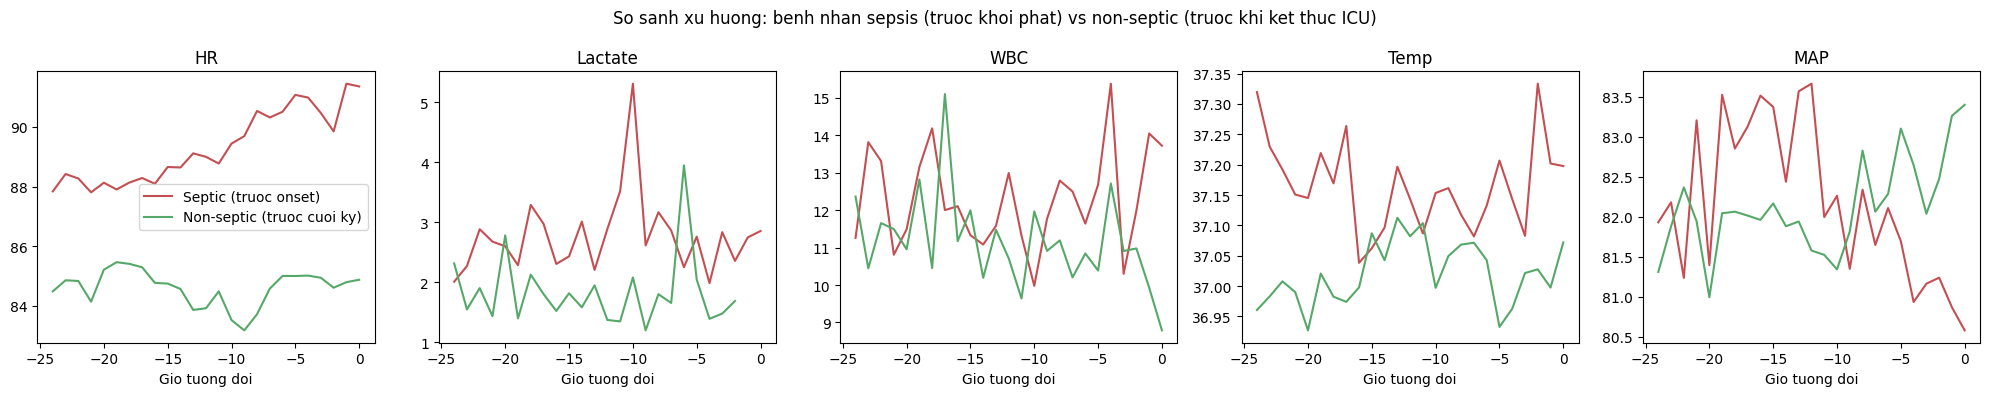

In [28]:
non_septic_ids = patient_label[patient_label["ever_sepsis"] == 0].index
non_septic_sample_ids = rng.choice(np.array(non_septic_ids), size=min(SAMPLE_SIZE, len(non_septic_ids)), replace=False)

records_control = []
for pid in non_septic_sample_ids:
    df = patients_by_id[pid]
    los = df["ICULOS"].max()
    rel_hours = df["ICULOS"] - los
    mask = (rel_hours >= -24) & (rel_hours <= 0)
    if mask.sum() == 0:
        continue
    sub = df.loc[mask, TRAJ_COLS].copy()
    sub["rel_hour"] = rel_hours[mask].round().astype(int)
    records_control.append(sub)

control_traj = pd.concat(records_control, ignore_index=True)

fig, axes = plt.subplots(1, len(TRAJ_COLS), figsize=(20, 4), sharex=True)
for ax, col in zip(axes, TRAJ_COLS):
    septic_mean = septic_traj.groupby("rel_hour")[col].mean()
    control_mean = control_traj.groupby("rel_hour")[col].mean()
    ax.plot(septic_mean.index, septic_mean.values, color="#C44E52", label="Septic (truoc onset)")
    ax.plot(control_mean.index, control_mean.values, color="#55A868", label="Non-septic (truoc cuoi ky)")
    ax.set_title(col)
    ax.set_xlabel("Gio tuong doi")
axes[0].legend()
fig.suptitle("So sanh xu huong: benh nhan sepsis (truoc khoi phat) vs non-septic (truoc khi ket thuc ICU)")
plt.tight_layout()
plt.show()

## 7. So sánh Set A vs Set B (ngoài missing)

Mục 2.1 đã so sánh tỉ lệ **thiếu** giữa Set A/B. Phần này mở rộng sang **giá trị đo được**: 2 hệ thống bệnh viện có thể dùng thiết bị/đơn vị/quy trình khác nhau, dẫn đến lệch phân phối dù cùng đo một đại lượng — điều này ảnh hưởng trực tiếp tới Luồng A vì hiện đang fit mean/std chuẩn hóa **toàn cục**, bỏ qua `source`.

source,A,B,abs_diff
AST,57.00,32.00,25.00
Alkalinephos,78.00,70.00,8.00
MAP,77.00,84.00,7.00
DBP,58.50,65.00,6.50
HospAdmTime,-2.60,-8.95,6.35
SBP,118.50,124.00,5.50
TroponinI,4.30,0.22,4.08
Glucose,124.00,128.00,4.00
BaseExcess,0.00,-2.40,2.40
Age,65.25,63.00,2.25


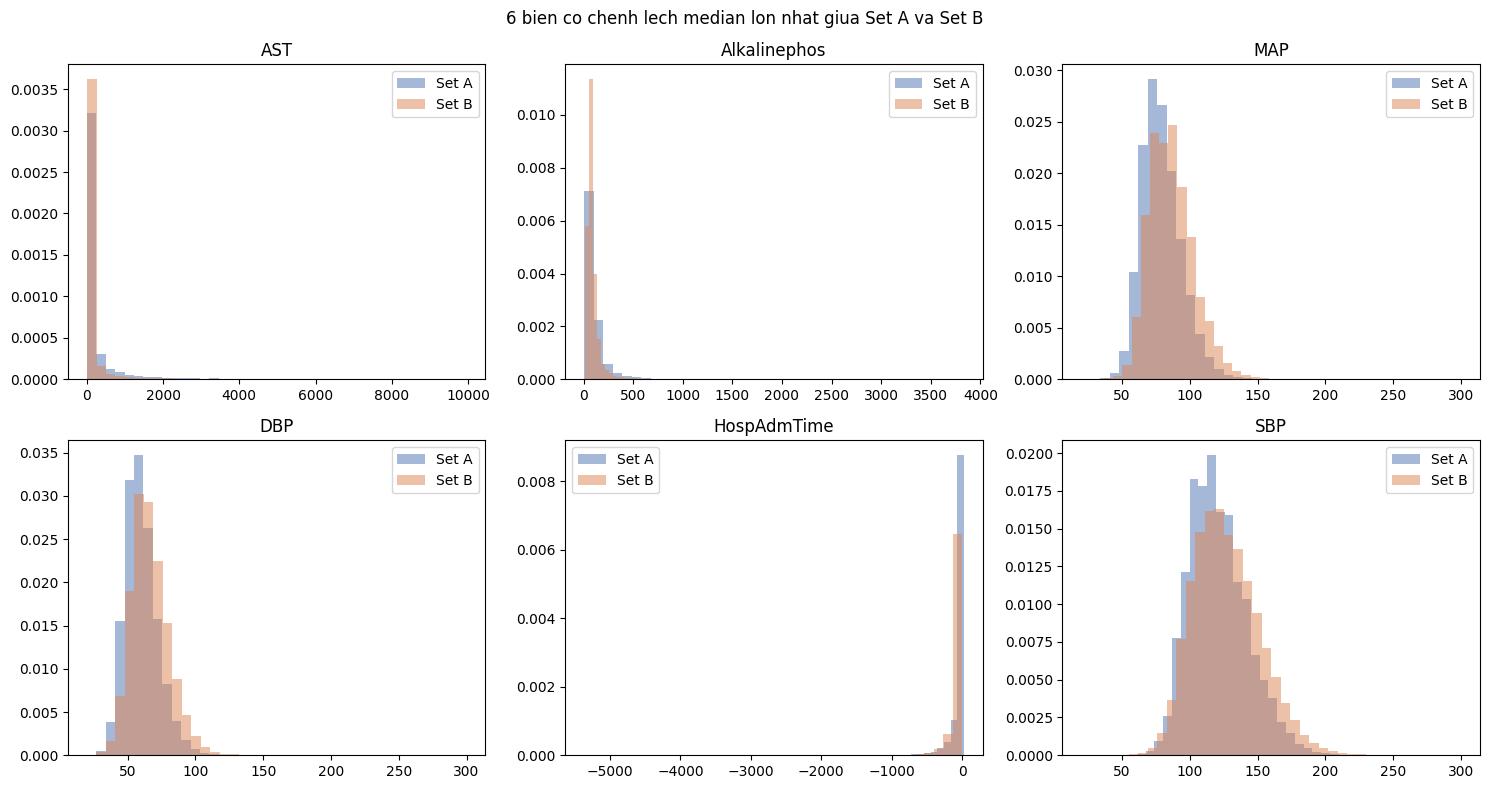

In [29]:
value_by_source = raw_df.groupby("source")[feature_cols].median().T
value_by_source["abs_diff"] = (value_by_source.get("A", 0) - value_by_source.get("B", 0)).abs()
value_by_source = value_by_source.sort_values("abs_diff", ascending=False)
display(value_by_source.round(2))

top_divergent = value_by_source.head(6).index
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), top_divergent):
    for src, color in zip(["A", "B"], ["#4C72B0", "#DD8452"]):
        vals = raw_df.loc[raw_df["source"] == src, col].dropna()
        ax.hist(vals, bins=40, alpha=0.5, density=True, color=color, label=f"Set {src}")
    ax.set_title(col)
    ax.legend()
fig.suptitle("6 bien co chenh lech median lon nhat giua Set A va Set B")
plt.tight_layout()
plt.show()

In [30]:
age_gender_by_patient = raw_df.groupby("patient_id").agg(
    source=("source", "first"), Age=("Age", "first"), Gender=("Gender", "first"),
)
display(age_gender_by_patient.groupby("source")[["Age", "Gender"]].describe())

sepsis_rate_by_source = patient_label.groupby("source")["ever_sepsis"].mean() * 100
display(sepsis_rate_by_source.rename("pct_patients_sepsis").round(2))

Age                                                           \
          count       mean        std    min    25%    50%    75%    max   
source                                                                     
A       20336.0  62.621613  16.236154  18.11  52.29  64.67  75.66   89.0   
B       20000.0  60.648800  16.671810  14.00  50.00  62.00  72.00  100.0   

         Gender                                               
          count      mean       std  min  25%  50%  75%  max  
source                                                        
A       20336.0  0.581924  0.493255  0.0  0.0  1.0  1.0  1.0  
B       20000.0  0.536600  0.498671  0.0  0.0  1.0  1.0  1.0

source
A    8.80
B    5.71
Name: pct_patients_sepsis, dtype: float64

## 8. Kiểm tra giả định impute & mask hiện tại

Ba giả định cụ thể trong `data/cleaning.py` và `data/feature-engineering.py` cần dữ liệu thật để đánh giá:

1. `forward_fill_impute` forward-fill **không giới hạn độ dài gap** — nếu gap NaN trong thực tế rất dài, một giá trị ffill từ nhiều giờ trước có thể trở nên vô nghĩa về sinh lý.
2. Impute dùng median theo cohort (Age, Gender) thay vì median toàn cục — chỉ đáng làm nếu cohort thực sự có median khác biệt rõ rệt.
3. `feature-engineering.py` chỉ có 1 mask feature (`EtCO2_mask`) — cần biết lab nào khác cũng đáng có mask riêng.

Mục 8.0 cần lặp per-patient (tính độ dài chuỗi NaN liên tiếp) nên dùng **mẫu** ~1000 bệnh nhân thay vì toàn bộ, giới hạn ở vitals + vài lab quan trọng để tránh chậm.

,count,mean,std,min,25%,50%,75%,max
column,,,,,,,,
Creatinine,1000.0,18.6,7.2,4.0,13.0,19.0,23.0,59.0
DBP,1000.0,10.3,15.3,0.0,1.0,2.0,15.0,83.0
EtCO2,1000.0,36.2,18.7,1.0,23.0,37.0,46.0,223.0
HR,1000.0,1.5,1.8,0.0,1.0,1.0,2.0,22.0
Lactate,1000.0,33.5,18.0,2.0,21.0,33.0,43.0,223.0
MAP,1000.0,2.0,3.3,0.0,1.0,1.0,2.0,58.0
O2Sat,1000.0,2.0,2.6,0.0,1.0,1.0,2.0,35.0
Platelets,1000.0,19.2,7.5,3.0,13.0,20.0,23.0,59.0
Resp,1000.0,2.4,3.8,0.0,1.0,1.0,3.0,59.0


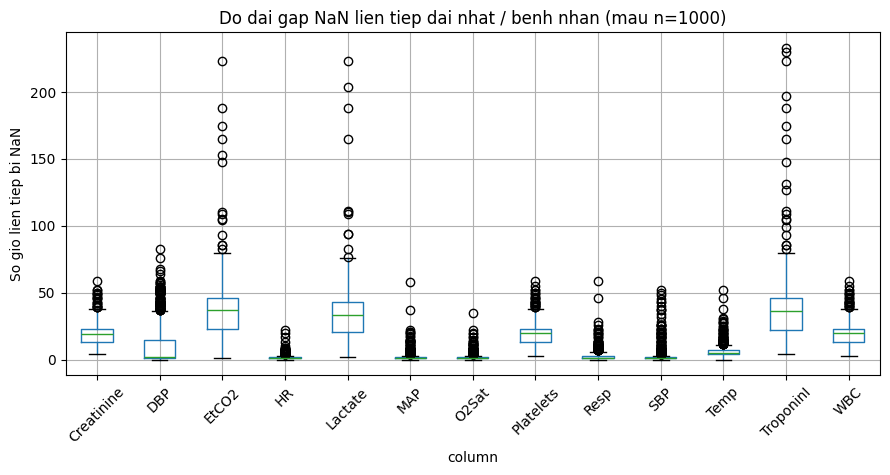

In [31]:
GAP_SAMPLE_SIZE = 1000
gap_check_cols = VITAL_COLS + ["Lactate", "Creatinine", "WBC", "Platelets", "TroponinI"]
gap_sample_ids = rng.choice(manifest["patient_id"].values, size=min(GAP_SAMPLE_SIZE, len(manifest)), replace=False)


def max_nan_run(series: pd.Series) -> int:
    is_na = series.isna().values
    max_run = run = 0
    for v in is_na:
        run = run + 1 if v else 0
        max_run = max(max_run, run)
    return max_run


gap_records = []
for pid in gap_sample_ids:
    df = patients_by_id[pid]
    for col in gap_check_cols:
        gap_records.append({"patient_id": pid, "column": col, "max_gap_hours": max_nan_run(df[col])})

gap_df = pd.DataFrame(gap_records)
display(gap_df.groupby("column")["max_gap_hours"].describe().round(1))

fig, ax = plt.subplots(figsize=(9, 5))
gap_df.boxplot(column="max_gap_hours", by="column", ax=ax, rot=45)
ax.set_title(f"Do dai gap NaN lien tiep dai nhat / benh nhan (mau n={len(gap_sample_ids)})")
ax.set_ylabel("So gio lien tiep bi NaN")
plt.suptitle("")
plt.tight_layout()
plt.show()

### 8.1 Median theo cohort (Age, Gender) so với median toàn cục

`fit_age_gender_normal_values` trong `cleaning.py` fit median riêng cho từng tổ hợp (Age, Gender). Kiểm tra median các cohort có thực sự tách biệt đáng kể so với median toàn cục hay không — nếu chênh lệch nhỏ, việc impute theo cohort không mang lại nhiều lợi ích so với dùng 1 median toàn cục đơn giản hơn.

In [32]:
COHORT_CHECK_COLS = ["HR", "Temp", "O2Sat"]
patient_first = raw_df.groupby("patient_id").agg(
    Age=("Age", "first"), Gender=("Gender", "first"),
    **{f"{c}_median": (c, "median") for c in COHORT_CHECK_COLS},
)
patient_first["age_bucket"] = pd.cut(patient_first["Age"], bins=[0, 40, 60, 75, 90, 100], include_lowest=True)

cohort_medians = patient_first.groupby(["age_bucket", "Gender"], observed=True)[[f"{c}_median" for c in COHORT_CHECK_COLS]].median()
global_medians = patient_first[[f"{c}_median" for c in COHORT_CHECK_COLS]].median()

display(cohort_medians.round(1))
print("Global median (toan bo benh nhan):")
display(global_medians.round(1))

cohort_spread = (cohort_medians - global_medians).abs()
print("Chenh lech tuyet doi giua median cohort va median toan cuc:")
display(cohort_spread.round(2))

HR_median  Temp_median  O2Sat_median
age_bucket     Gender                                      
(-0.001, 40.0] 0            89.0         36.8          98.5
               1            87.5         36.9          98.0
(40.0, 60.0]   0            84.0         36.8          98.0
               1            84.0         36.9          97.5
(60.0, 75.0]   0            82.0         36.8          98.0
               1            81.0         36.9          97.0
(75.0, 90.0]   0            80.0         36.8          98.0
               1            80.0         36.8          97.5
(90.0, 100.0]  0            78.0         36.6          97.0
               1            75.5         36.6          97.0

Global median (toan bo benh nhan):


HR_median       82.0
Temp_median     36.8
O2Sat_median    98.0
dtype: float64

Chenh lech tuyet doi giua median cohort va median toan cuc:


HR_median  Temp_median  O2Sat_median
age_bucket     Gender                                      
(-0.001, 40.0] 0             7.0         0.02           0.5
               1             5.5         0.12           0.0
(40.0, 60.0]   0             2.0         0.00           0.0
               1             2.0         0.06           0.5
(60.0, 75.0]   0             0.0         0.03           0.0
               1             1.0         0.03           1.0
(75.0, 90.0]   0             2.0         0.08           0.0
               1             2.0         0.05           0.5
(90.0, 100.0]  0             4.0         0.28           1.0
               1             6.5         0.28           1.0

### 8.2 Lab nào đáng có mask feature riêng?

`feature-engineering.py` chỉ tạo `EtCO2_mask`. Xếp hạng các lab theo % thiếu (mục 2) **và** độ mạnh tương quan với `SepsisLabel` (mục 5.2) để tìm ứng viên ưu tiên — lab vừa thiếu nhiều vừa có tín hiệu với sepsis là ứng viên tốt nhất cho 1 mask feature mới (vì bản thân việc "có được đo hay không" mang thông tin, như đã thấy ở mục 2.2).

In [33]:
mask_candidates = missing_summary[missing_summary["group"] == "lab"][["column", "pct_missing"]].merge(
    corr_with_label.abs().rename("abs_corr_with_sepsis_label").reset_index().rename(columns={"index": "column"}),
    on="column", how="left",
)
mask_candidates = mask_candidates.sort_values(["pct_missing", "abs_corr_with_sepsis_label"], ascending=[False, False])
display(mask_candidates.head(15).round(3))
print("Lab co missing cao VA tuong quan voi SepsisLabel dang ke la ung vien uu tien cho mask feature rieng (ngoai EtCO2_mask da co).")

,column,pct_missing,abs_corr_with_sepsis_label
0,Bilirubin_direct,99.807,0.058
1,Fibrinogen,99.340,0.048
2,TroponinI,99.048,0.007
3,Bilirubin_total,98.509,0.048
4,Alkalinephos,98.393,0.013
5,AST,98.378,0.008
6,Lactate,97.330,0.007
7,PTT,97.056,0.017
8,SaO2,96.549,0.010
9,Phosphate,95.986,0.020


Lab co missing cao VA tuong quan voi SepsisLabel dang ke la ung vien uu tien cho mask feature rieng (ngoai EtCO2_mask da co).


## 9. Ngưỡng qSOFA/NEWS & trọng số lớp

Hai kiểm tra cuối, đối chiếu giả định lâm sàng/mô hình với phân phối thật:

- `feature-engineering.py` tính qSOFA rút gọn (`SBP < 100` → +1, `Resp >= 20` → +1) và NEWS rút gọn với các mốc ngưỡng cố định trên Resp/O2Sat/SBP/HR/Temp. Vẽ đè các ngưỡng này lên histogram thật để xem chúng có rơi vào vùng "luôn trigger" hoặc "gần như không bao giờ trigger" (tức không phân biệt được gì) hay không.
- `reproduce/` dùng trọng số cố định pos:neg = 40:1 cho custom loss. So với tỉ lệ mất cân bằng lớp **thật** trên dataset này.

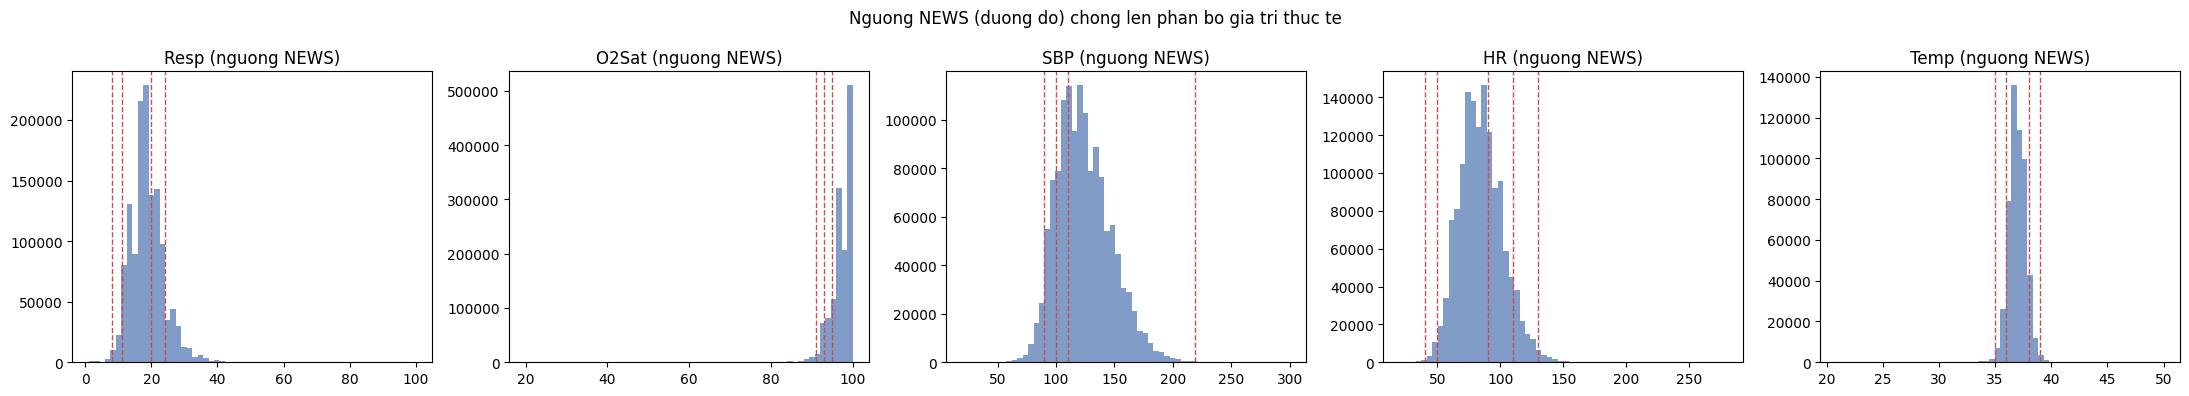

In [34]:
NEWS_THRESHOLDS = {
    "Resp": [8, 11, 20, 24],
    "O2Sat": [91, 93, 95],
    "SBP": [90, 100, 110, 219],
    "HR": [40, 50, 90, 110, 130],
    "Temp": [35.0, 36.0, 38.0, 39.0],
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (col, thresholds) in zip(axes, NEWS_THRESHOLDS.items()):
    vals = raw_df[col].dropna()
    ax.hist(vals, bins=60, color="#4C72B0", alpha=0.7)
    for t in thresholds:
        ax.axvline(t, color="#C44E52", linestyle="--", linewidth=1)
    ax.set_title(f"{col} (nguong NEWS)")
fig.suptitle("Nguong NEWS (duong do) chong len phan bo gia tri thuc te")
plt.tight_layout()
plt.show()

In [35]:
n_pos = int((raw_df["SepsisLabel"] == 1).sum())
n_neg = int((raw_df["SepsisLabel"] == 0).sum())
print(f"So dong SepsisLabel=1: {n_pos:,} | =0: {n_neg:,}")
print(f"Ty le am:duong thuc te = {n_neg / n_pos:.1f} : 1 (Luong A dung trong so co dinh 40:1)")

ratio_by_source = raw_df.groupby("source")["SepsisLabel"].agg(
    n_pos=lambda s: (s == 1).sum(), n_neg=lambda s: (s == 0).sum()
)
ratio_by_source["neg_to_pos_ratio"] = ratio_by_source["n_neg"] / ratio_by_source["n_pos"]
display(ratio_by_source.round(1))

So dong SepsisLabel=1: 27,916 | =0: 1,524,294
Ty le am:duong thuc te = 54.6 : 1 (Luong A dung trong so co dinh 40:1)


,n_pos,n_neg,neg_to_pos_ratio
source,,,
A,17136,773079,45.1
B,10780,751215,69.7
